In [1]:
!pip install transformers torch torchvision matplotlib scikit-learn

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.metrics.pairwise import cosine_similarity
from transformers import CLIPProcessor, CLIPModel
from google.colab import files

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
print("✅ CLIP model loaded!")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

✅ CLIP model loaded!


In [4]:
print("Upload 2 or more images:")
uploaded = files.upload()

image_list = []
image_names = []

for name in uploaded.keys():
    img = Image.open(name).convert("RGB")
    image_list.append(img)
    image_names.append(name)

print("✅ Images Loaded:", image_names)

Upload 2 or more images:


Saving Screenshot 2026-02-11 175528.png to Screenshot 2026-02-11 175528.png
Saving Screenshot 2026-02-13 131609.png to Screenshot 2026-02-13 131609.png
Saving Screenshot 2026-02-13 131642.png to Screenshot 2026-02-13 131642.png
✅ Images Loaded: ['Screenshot 2026-02-11 175528.png', 'Screenshot 2026-02-13 131609.png', 'Screenshot 2026-02-13 131642.png']


In [7]:
image_embeddings = []

for img in image_list:
    inputs = processor(images=img, return_tensors="pt").to(device)

    with torch.no_grad():
        outputs = model.get_image_features(**inputs)

    emb = outputs.pooler_output.cpu().numpy()[0]

    # Normalize embedding
    emb = emb / np.linalg.norm(emb)

    image_embeddings.append(emb)

image_embeddings = np.array(image_embeddings)

print("✅ Embeddings shape:", image_embeddings.shape)

✅ Embeddings shape: (3, 512)


In [8]:
similarity_matrix = cosine_similarity(image_embeddings)

print("\n📊 Cosine Similarity Matrix:\n")
print(similarity_matrix)


📊 Cosine Similarity Matrix:

[[1.0000001  0.39420727 0.3538409 ]
 [0.39420727 1.0000001  0.9334775 ]
 [0.3538409  0.9334775  1.0000001 ]]


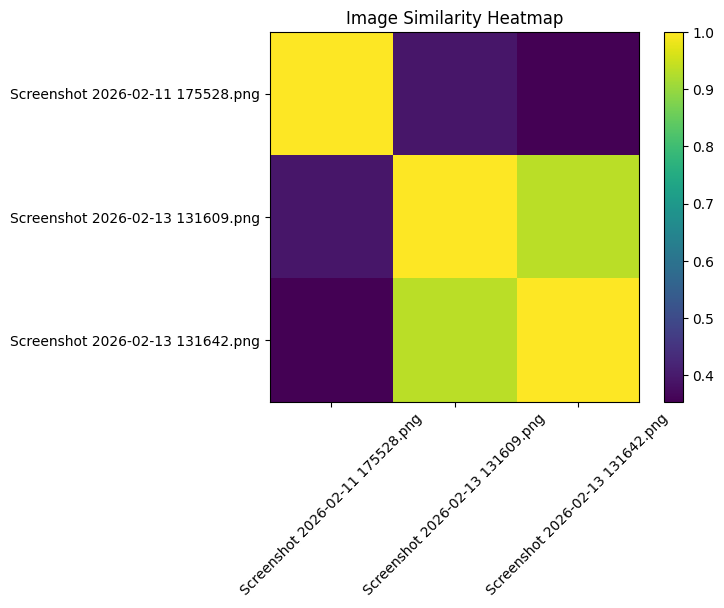

In [9]:
plt.figure()
plt.imshow(similarity_matrix)
plt.colorbar()
plt.xticks(range(len(image_names)), image_names, rotation=45)
plt.yticks(range(len(image_names)), image_names)
plt.title("Image Similarity Heatmap")
plt.show()

In [10]:
print("\n🔍 Pairwise Similarities:\n")

for i in range(len(image_names)):
    for j in range(i+1, len(image_names)):
        print(f"{image_names[i]} vs {image_names[j]} = {similarity_matrix[i][j]:.4f}")


🔍 Pairwise Similarities:

Screenshot 2026-02-11 175528.png vs Screenshot 2026-02-13 131609.png = 0.3942
Screenshot 2026-02-11 175528.png vs Screenshot 2026-02-13 131642.png = 0.3538
Screenshot 2026-02-13 131609.png vs Screenshot 2026-02-13 131642.png = 0.9335


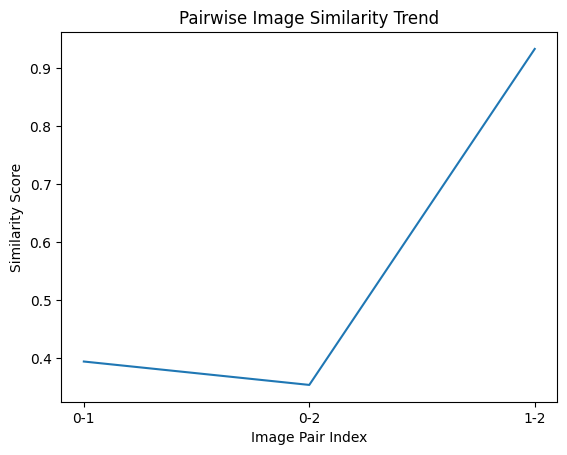

In [11]:
# Flatten upper triangle values
values = []
labels = []

for i in range(len(image_names)):
    for j in range(i+1, len(image_names)):
        values.append(similarity_matrix[i][j])
        labels.append(f"{i}-{j}")

plt.figure()
plt.plot(values)
plt.xticks(range(len(labels)), labels)
plt.xlabel("Image Pair Index")
plt.ylabel("Similarity Score")
plt.title("Pairwise Image Similarity Trend")
plt.show()

In [12]:
def interpret(score):
    if score > 0.9:
        return "Highly Similar (almost same)"
    elif score > 0.7:
        return "Moderately Similar"
    elif score > 0.4:
        return "Slight Similarity"
    else:
        return "Very Different"

print("\n📘 Interpretation:\n")

for i in range(len(image_names)):
    for j in range(i+1, len(image_names)):
        score = similarity_matrix[i][j]
        print(f"{image_names[i]} vs {image_names[j]} → {interpret(score)}")


📘 Interpretation:

Screenshot 2026-02-11 175528.png vs Screenshot 2026-02-13 131609.png → Very Different
Screenshot 2026-02-11 175528.png vs Screenshot 2026-02-13 131642.png → Very Different
Screenshot 2026-02-13 131609.png vs Screenshot 2026-02-13 131642.png → Highly Similar (almost same)
